(500, 6)
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


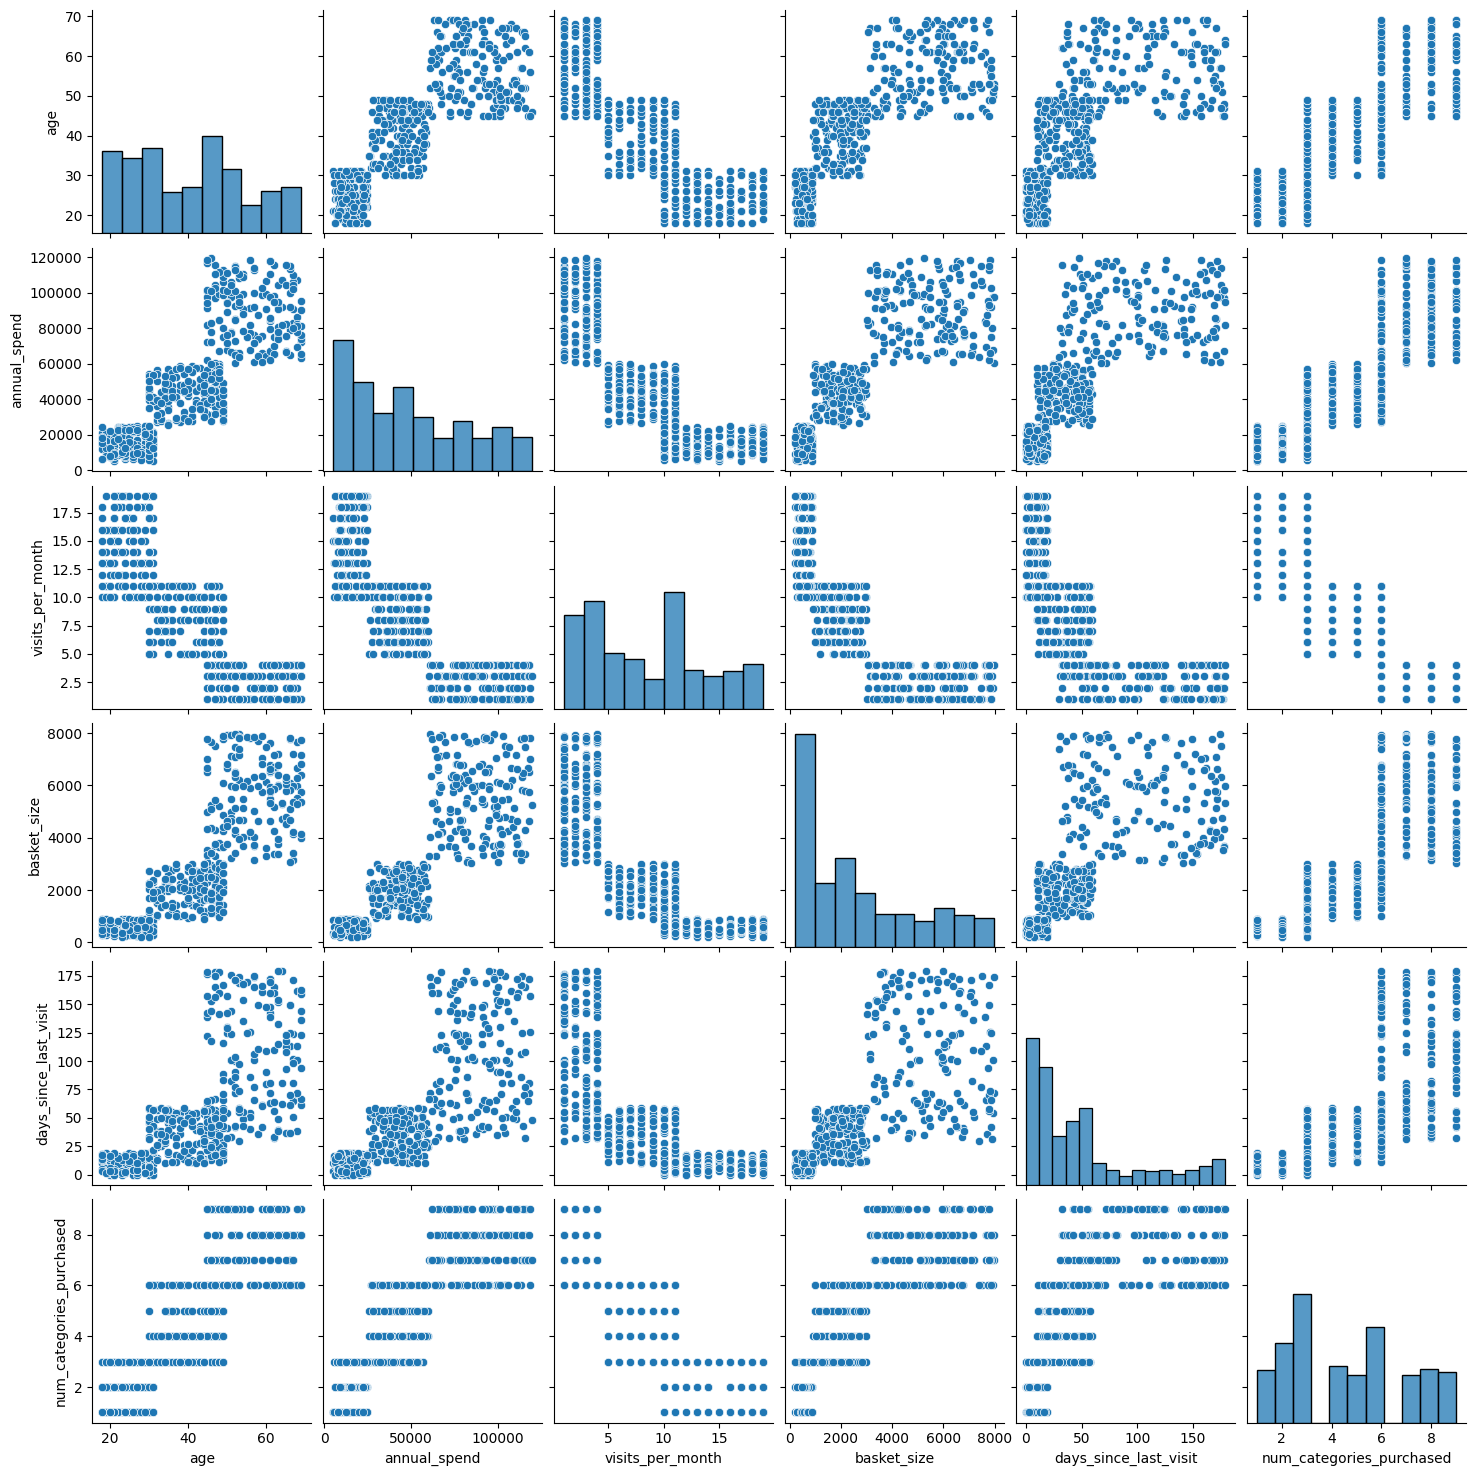

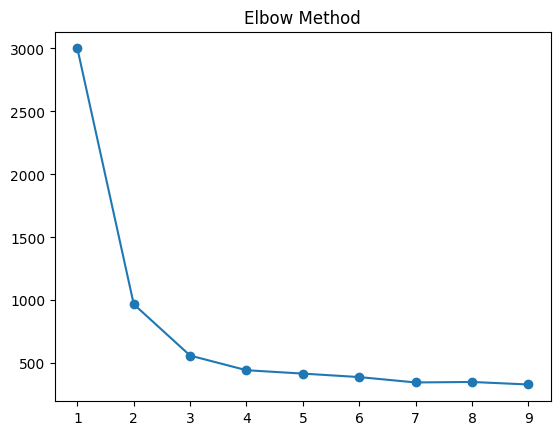

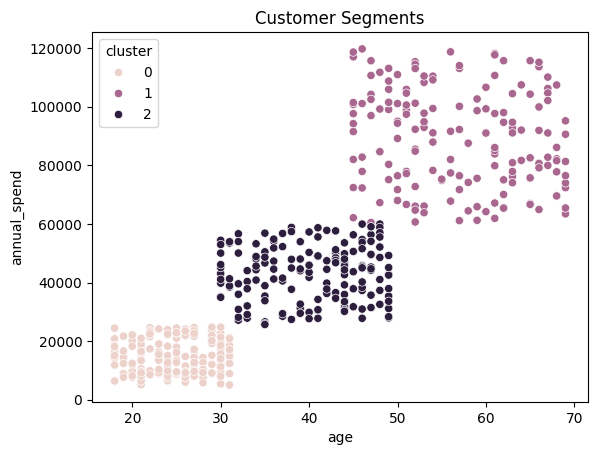

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# load data
df = pd.read_csv('q2_customers.csv')

print(df.shape)
print(df.head())

# pairplot
sns.pairplot(df)
plt.show()

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# elbow method
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

# kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# visualization
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1], hue=df['cluster'])
plt.title("Customer Segments")
plt.show()

Customers are grouped into 3 clusters based on their characteristics.
Each cluster represents a different segment of customers with similar behavior.
This helps businesses understand and target different customer groups effectively.